In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

🌟 **Exercise 1** : Exploratory Data Analysis

- Load the data from CSV files

In [2]:
df = pd.read_csv('dataset_heart.csv')
df.head()

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1


- Remove target column from the training data

In [3]:
X = df.drop(columns=['heart disease'])
y = df['heart disease'] # target variable

- Split the data intro train/test split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

- Understand the data

In [5]:
df.describe()

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,1.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,1.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,2.000000


In [6]:
# Missing values
df.isnull().sum()

,0
age,0
sex,0
chest pain type,0
resting blood pressure,0
serum cholestoral,0
fasting blood sugar,0
resting electrocardiographic results,0
max heart rate,0
exercise induced angina,0
oldpeak,0


In [7]:
# Distribution of target variable
df['heart disease'].value_counts()

,count
heart disease,
1,150
2,120


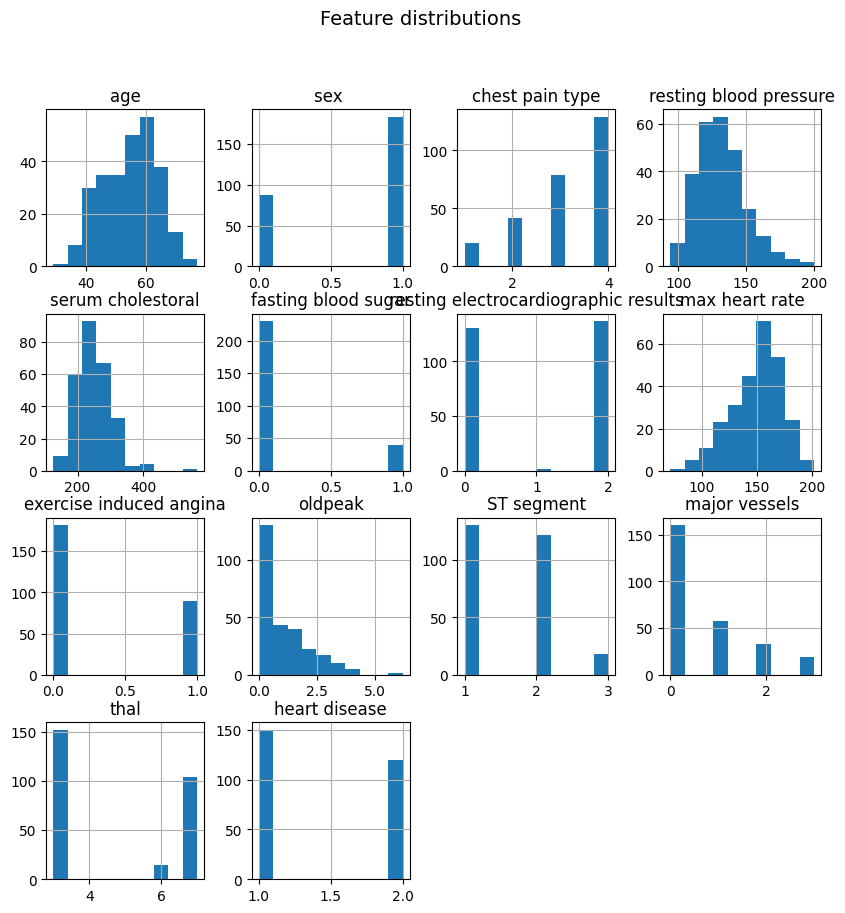

In [8]:
# Visualize feature distributions
df.hist(figsize=(10,10))
plt.suptitle('Feature distributions', fontsize=14)
plt.show()

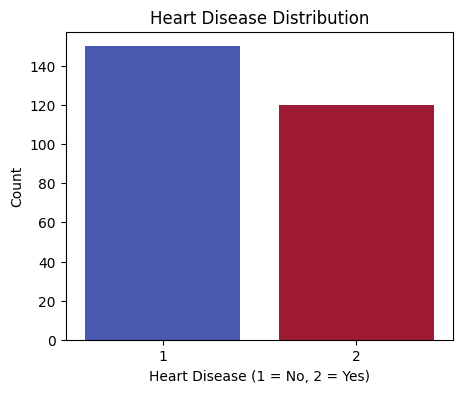

In [9]:
# Visualize the target variable
plt.figure(figsize=(5,4))
sns.countplot(x=df["heart disease"], hue=df["heart disease"], palette="coolwarm", legend=False)
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (1 = No, 2 = Yes)")
plt.ylabel("Count")
plt.show()


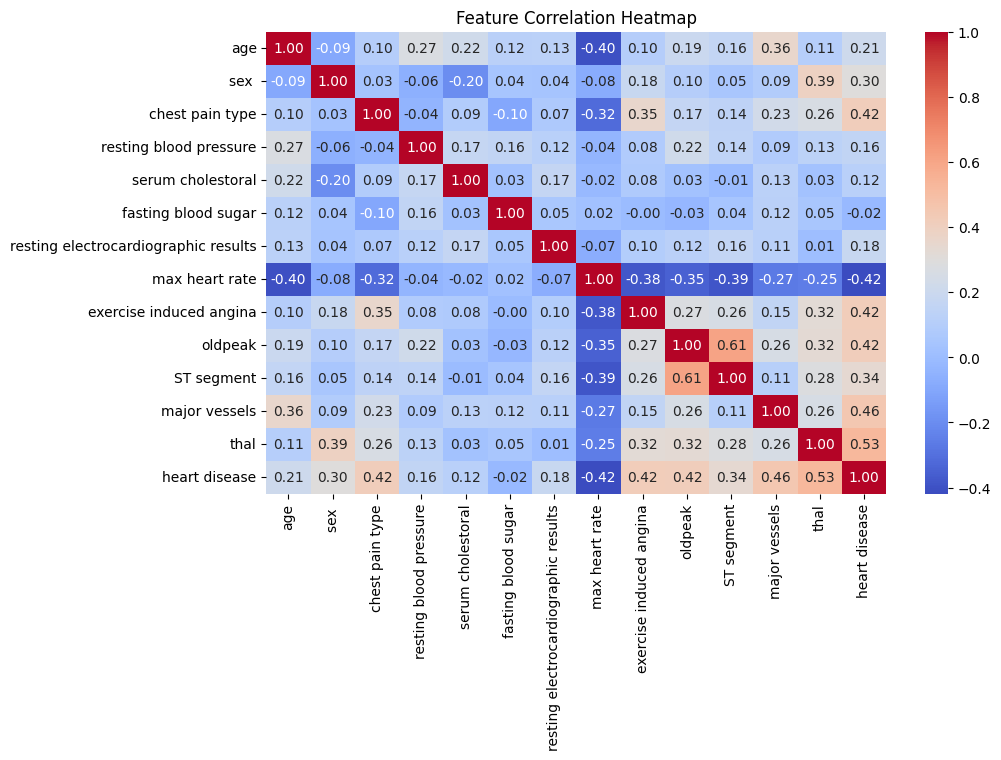

In [10]:
# Check correlatioon between features
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

🌟 **Exercise 2** : Logistic Regression without Grid Search

Use the dataset to build a logistic regression model without using grid search. Split the data into training and testing sets, then train a logistic regression model and evaluate its performance on the test set.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)


- Accuracy

In [12]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [13]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.91


- Confusion Matrix

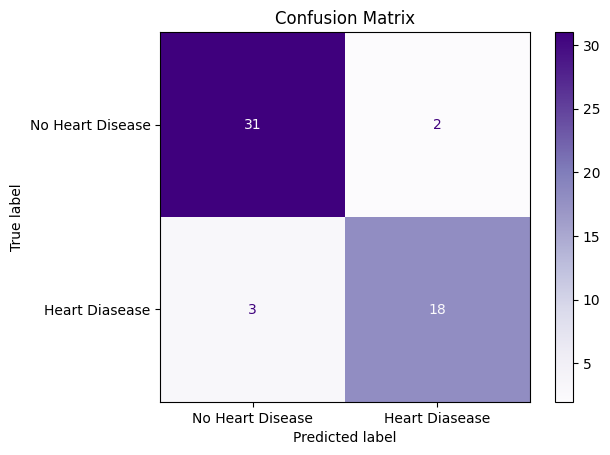

In [14]:
conf_matrix = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["No Heart Disease", "Heart Diasease"])
disp.plot(cmap="Purples", values_format="d")
plt.title("Confusion Matrix")
plt.show()

The model achieve an **accuracy of 91%**, meaning 91% of predictions were **correct**. This suggests that the logistic regression model performs well in predicting heart disease.

**Confusion matrix :**

- **True Positives (TP = 18)** → 18 patients were correclty diagnosed with heart disease.
- **True Negatives (TN = 31)** → 31 patients were correcltly classified as not having heart disease.
- **False Positives (FP = 2)** → 2 patients were predicted to have heart disease but actually did not (flase alarm).
- **False Negatives (FN = 3)** → 3 patients were predicted as not having heart disease but actually did (missed cases).

The model succesfuly detect most cases of heart disease with low false negatives (FN=3). False positives (FP=2) are minimal, meaning the model does not raise too many false alarms.
**However, missing 3 real heart disease cases (FN) could be a concern in medical diagnosis.**

🌟 **Exercise 3** : Logistic Regression with Grid Search

Build a logistic regression model using the dataset, but this time, use GridSearchCV to optimize the hyperparameters such as C and penalty.



In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold

# Creating the hyperparameter grid
c_space = np.logspace(-3, 3, 10) # Tries 15 values from 10^-5 to 10^8
param_grid = {'C': c_space,
              'penalty' : ['l1', 'l2'] # 'l1':lasso, 'l2':ridge
              }

# Instantiating logistic regression classifier
logreg = LogisticRegression(solver='liblinear')

# Instantiating the GridSearchCV object
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
logreg_cv = GridSearchCV(logreg, param_grid, cv=cv)  # cv=5, Uses 5-fold cross-validation
                                                    # splits data into 5 parts, trains on 4, tests on 1

# Fit the GridSearchCV object to the data
logreg_cv.fit(X_train_scaled, y_train)

# Print the tuned parameters and score
print("Tuned Logistic Regression Parameters: {}".format(logreg_cv.best_params_))
print("Best score is {}".format(logreg_cv.best_score_))

# Accuracy
y_pred = logreg_cv.best_estimator_.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy with Best Parameters: {test_accuracy:.2f}")


Tuned Logistic Regression Parameters: {'C': 0.1, 'penalty': 'l2'}
Best score is 0.8330866807610994
Test Accuracy with Best Parameters: 0.93


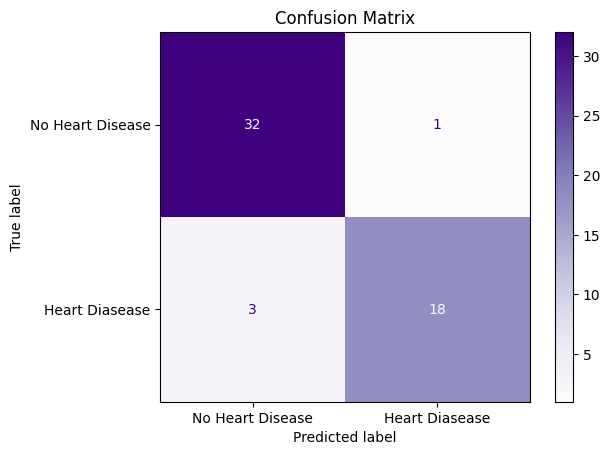

In [16]:
conf_matrix = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["No Heart Disease", "Heart Diasease"])
disp.plot(cmap="Purples", values_format="d")
plt.title("Confusion Matrix")
plt.show()

With *GridSearchCV*, we found the best combination of **C (regularization strength) and penalty type (L1 or L2).**

- Best C value found : **C = 0.1** (C=1.0 in exercise 2, default) Here, C=0.1 means the model found a balance between preventing overfitting and capturing enough information.
- Best regularization (penalty) : **l2** (Ridge Regularization, keeps all features but reduces their impact, prevents overfitting, while L1 can eliminate some features, selection). SInce *GridSearchCV* picked **L2**, this suggests **all features contributed to the model.**
- Cross-validation score (cv=5) : **83.3%** (while we used only a single train-test split for exercise 2, here *GridSearchCV* tested 5 different splits).
- Accuracy : **93%** (higher than 91% from exercise 2)

The model is now more stable and generalizes better, leading to a higher test accuracy. It reduced the risk of overfitting on a single train-test split. L2 regularization helped improve generalization without dropping important features.

🌟 **Exercise 4** : SVM without Grid Search

Train a Support Vector Machine (SVM) classifier on the dataset without using grid search. Choose an appropriate kernel and set the hyperparameters manually.

In [17]:
from sklearn.svm import SVC

# Create and train the Support Vector Classifier
svc_model = SVC(kernel='linear', C=0.1, gamma='scale', random_state=42)
svc_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
svc_y_pred = svc_model.predict(X_test_scaled)

# Calculate accuracy
svc_accuracy = accuracy_score(y_test, svc_y_pred)
print(f'Accuracy (SVC): {svc_accuracy:.2f}')

Accuracy (SVC): 0.91


🌟 **Exercise 5** : SVM with Grid Search

Implement an SVM classifier on the dataset with GridSearchCV to find the best combination of C, kernel, and gamma hyperparameters.

In [18]:
param_grid = {
    'C' : [0.005, 0.01, 0.05, 0.1, 0.5, 10, 100],
    'kernel' : ['linear', 'rbf', 'poly'],
    'gamma' : ['scale', 'auto']
}

svc_model = SVC(random_state=42)

# Stratified cross-validation for better class balance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform GridSearchCV
svc_cv = GridSearchCV(svc_model, param_grid, cv=cv)
svc_cv.fit(X_train_scaled, y_train)

# Print the best parameters and score
print("Tuned SVM Parameters: {}".format(svc_cv.best_params_))
print("Best score is {}".format(svc_cv.best_score_))

# Evaluate on test data
svc_y_pred = svc_cv.best_estimator_.predict(X_test_scaled)
svc_accuracy = accuracy_score(y_test, svc_y_pred)
print(f"Test Accuracy with Best Parameters: {svc_accuracy:.2f}")

Tuned SVM Parameters: {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
Best score is 0.8330866807610994
Test Accuracy with Best Parameters: 0.89


- The manually chosen SVM (C=0.1, kernel='linear') from exercise 4 gave **90.7% accuracy**, while *GridSearchCV* consistently finds **89%**. The manually model might have slightly overfitted the train-test split. It was trained on only **one fixed** train-test split, while *GridSearchCV* used multiple train-test splits (cv=5), leading to a **more generalizable model**.
- If the manually tuned model was truly better, *GridSearchCV* **should have found similar hyperparameters**. It optimizes for cross-validation score, not the test accuracy directly. It chose a model **that performes consistently across different splits**. It found a **more robust model, even if its test accuracy is slightly lower**.

🌟 **Exercise 6** : XGBoost without Grid Search

Use the dataset to train an XGBoost classifier without hyperparameter tuning. Set the hyperparameters manually and justify your choices.

In [19]:
from xgboost import XGBClassifier

# Convert target variable from [1,2] to [0,1]
y_train_adjusted = y_train - 1
y_test_adjusted = y_test - 1

# Create and train the XGBoost classifier
model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train_scaled, y_train_adjusted)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test_adjusted, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.85


🌟 **Exercise 7** : XGBoost with Grid Search

Train an XGBoost classifier on the dataset using GridSearchCV to optimize hyperparameters such as learning_rate, n_estimators, max_depth, etc.



In [20]:
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5]
}

# Create an XGBoost classifier
xgb_model = XGBClassifier(random_state=42)

# Stratified cross-validation for better class balance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform GridSearchCV
xgb_cv = GridSearchCV(xgb_model, param_grid, cv=cv)
xgb_cv.fit(X_train_scaled, y_train_adjusted)

# Print the best parameters and score
print("Tuned XGBoost Parameters: {}".format(xgb_cv.best_params_))
print("Best Cross-Validation score is {}".format(xgb_cv.best_score_))

# Evaluate on test data
xgb_y_pred = xgb_cv.best_estimator_.predict(X_test_scaled)
xgb_accuracy = accuracy_score(y_test_adjusted, xgb_y_pred)
print(f"Test Accuracy with Best Parameters: {xgb_accuracy:.2f}")

Tuned XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best Cross-Validation score is 0.7820295983086681
Test Accuracy with Best Parameters: 0.89


- In exercise 6 without Grid Search, we set the hyperparameters manually :
 - n_estimators: 100
 - max_depth: 5
 - learning_rate: 0.1

 It gave **85% accuracy**.

- In exercise 7 with Grid Search, the model found better hyperparameters :
 - n_estimators: 50
 - max_depth: 3
 - learning_rate: 0.1

 It gave **89% accuracy** (better than without Grid Search).